# 06 Rule-based (regex) 


## 1. Setup + CONFIG

In [10]:
import re, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_recall_fscore_support, accuracy_score, classification_report, confusion_matrix
from scipy.stats import binomtest
plt.rcParams["font.family"]="sans-serif"; plt.rcParams["font.sans-serif"]=["Calibri","Arial","DejaVu Sans"]
NAVY,GREEN,GREY="#085384","#1B4332","#9bb1c4"

# CONFIG 
INPUT_CSV = "cleaned_comments_ver2.csv"   
GOLD_CSV  = "label_done_150.csv"              
ID_COL, TEXT_COL = "Document ID", "comment_text"
SEED = 42
TOPIC_CODES = ["oil_spill_risk","climate_emissions","air_quality","environmental_justice",
               "marine_wildlife","fisheries","wetlands_coast","national_interest"]

## 2. topics + stance

In [11]:
TOPIC_PATTERNS = {
 "oil_spill_risk":       [r"\boil spill", r"\bdeepwater horizon", r"\bspill risk", r"\bcatastrophic"],
 "climate_emissions":    [r"\bclimate change", r"\bgreenhouse gas", r"\bemissions?", r"\bfossil fuel"],
 "air_quality":          [r"\bair quality", r"\bair pollution", r"\bozone", r"\bnox\b"],
 "environmental_justice":[r"\benvironmental justice", r"\benvironmental racism", r"\blow-income", r"\bminority communities"],
 "marine_wildlife":      [r"\bsea turtle", r"\bmarine mammals?", r"\bdolphin", r"\bwhale", r"\bblack rail", r"\bhabitats?"],
 "fisheries":            [r"\bfisher(?:y|ies)", r"\bshrimp", r"\bcommercial fishing", r"\bfishermen"],
 "wetlands_coast":       [r"\bwetlands?", r"\bcoastline", r"\berosion", r"\bstorm surge", r"\bsea level rise", r"\bflood"],
 "national_interest":    [r"\bnational interest", r"\bnot in the national interest"],
}
OPPOSE  = r"\b(?:oppose|opposition|deny|reject|not in the national interest|concerned)\b"
SUPPORT = r"\b(?:support|approve|in favor|favour)\b"


## 3. Label the FULL docket 

In [12]:
df = pd.read_csv(INPUT_CSV, low_memory=False)
def topics_for(t):
    t=str(t); return [c for c,pats in TOPIC_PATTERNS.items() if any(re.search(p,t,re.IGNORECASE) for p in pats)]
df["regex_topics"] = df[TEXT_COL].apply(lambda t: "|".join(topics_for(t)) or "NONE")
def stance_for(row):
    t=str(row[TEXT_COL])
    if str(row.get("submission_source","")).startswith("Attachment only"): return "unclear"
    if re.search(OPPOSE,t,re.IGNORECASE):  return "oppose"
    if re.search(SUPPORT,t,re.IGNORECASE): return "support"
    return "unclear"
df["regex_stance"] = df.apply(stance_for, axis=1)
df[[ID_COL,TEXT_COL,"regex_topics","regex_stance"]].to_csv("regex_scenario_labels.csv", index=False)
print(f"labelled all {len(df):,} comments -> regex_scenario_labels.csv")


labelled all 10,195 comments -> regex_scenario_labels.csv


## 4. Distribution 

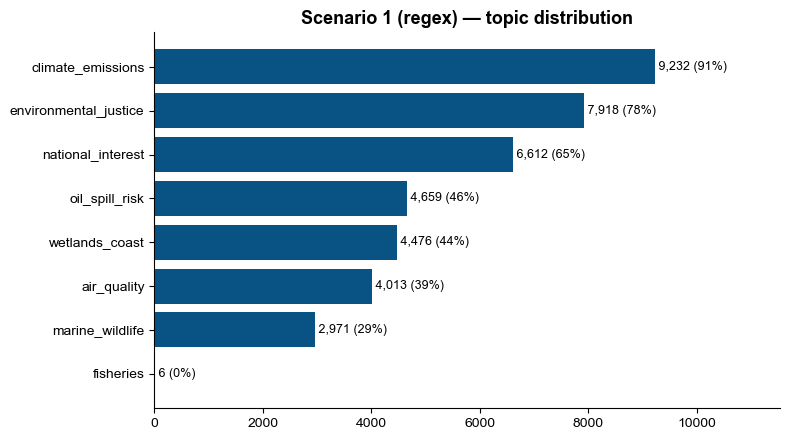

stance: {'oppose': 7736, 'unclear': 2211, 'support': 248}


In [13]:
from collections import Counter
c=Counter()
for s in df["regex_topics"]:
    for t in str(s).split("|"):
        if t and t!="NONE": c[t]+=1
items=sorted(c.items(),key=lambda x:x[1]); labs=[k for k,_ in items]; vals=[v for _,v in items]; N=len(df)
fig,ax=plt.subplots(figsize=(8,4.5)); ax.barh(labs,vals,color=NAVY)
for i,v in enumerate(vals): ax.text(v,i,f" {v:,} ({v/N*100:.0f}%)",va="center",fontsize=9)
ax.set_title("Scenario 1 (regex) — topic distribution",fontsize=13,weight="bold"); ax.set_xlim(0,max(vals)*1.25)
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("regex_topic_distribution.png",dpi=150,facecolor="white"); plt.show()
print("stance:", df["regex_stance"].value_counts().to_dict())


---
## 5. PRECISION / RECALL / F1 test (regex vs gold)


In [14]:
gold = pd.read_csv(GOLD_CSV)
E = gold.merge(df[[ID_COL,"regex_topics","regex_stance","stance"]], on=ID_COL, how="left")
E = E[E["gold_topics"].notna()].copy()
print(f"evaluating on {len(E)} gold rows")

def parse(s): return [t for t in str(s).replace(" ","").split("|") if t in TOPIC_CODES]
mlb = MultiLabelBinarizer(classes=TOPIC_CODES)
Y = mlb.fit_transform(E["gold_topics"].apply(parse))      # gold
R = mlb.transform(E["regex_topics"].apply(parse))         # regex predictions


evaluating on 150 gold rows


In [15]:

def boot_ci(y,p,avg="micro",n=1000):
    rng=np.random.default_rng(SEED); v=[]
    for _ in range(n):
        idx=rng.integers(0,len(y),len(y))
        _,_,f,_=precision_recall_fscore_support(y[idx],p[idx],average=avg,zero_division=0); v.append(f)
    return np.percentile(v,2.5),np.percentile(v,97.5)

print("TOPIC — regex vs gold")
for avg in ["micro","macro"]:
    p,r,f,_=precision_recall_fscore_support(Y,R,average=avg,zero_division=0)
    extra=f"  (95% CI {boot_ci(Y,R)[0]:.3f}-{boot_ci(Y,R)[1]:.3f})" if avg=="micro" else ""
    print(f"  {avg}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}{extra}")


TOPIC — regex vs gold
  micro: Precision=0.866  Recall=0.714  F1=0.783  (95% CI 0.746-0.817)
  macro: Precision=0.845  Recall=0.652  F1=0.714


                topic  support  precision  recall   f1
       oil_spill_risk       57       0.96    0.77 0.85
    climate_emissions      113       0.98    0.90 0.94
          air_quality       63       0.91    0.48 0.62
environmental_justice       40       0.78    0.88 0.82
      marine_wildlife       54       0.97    0.69 0.80
            fisheries       15       0.75    0.20 0.32
       wetlands_coast       50       0.63    0.68 0.65
    national_interest       62       0.78    0.63 0.70

Low recall = regex MISSES that topic (paraphrases it can't catch).
Low precision = regex OVER-fires that topic (matches too loosely).


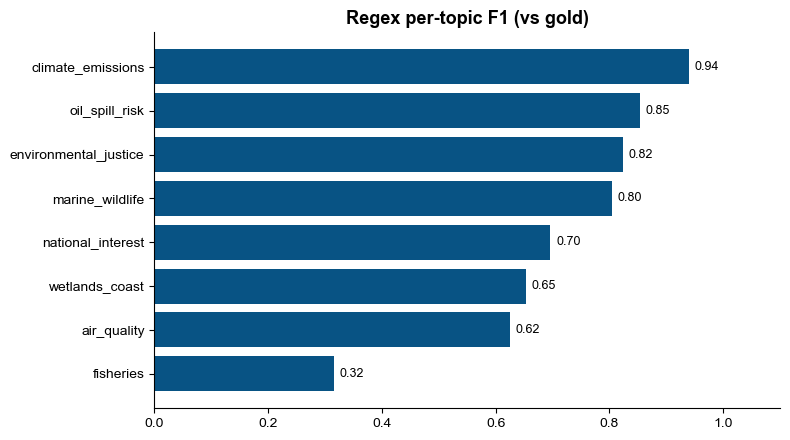

In [16]:

p,r,f,sup=precision_recall_fscore_support(Y,R,average=None,zero_division=0,labels=range(len(TOPIC_CODES)))
tbl=pd.DataFrame({"topic":TOPIC_CODES,"support":sup,"precision":p,"recall":r,"f1":f}).round(2)
print(tbl.to_string(index=False))
print("\nLow recall = regex MISSES that topic (paraphrases it can't catch).")
print("Low precision = regex OVER-fires that topic (matches too loosely).")

# per-topic F1 bar
order=np.argsort(f)
fig,ax=plt.subplots(figsize=(8,4.5)); ax.barh([TOPIC_CODES[i] for i in order],[f[i] for i in order],color=NAVY)
for y,i in enumerate(order): ax.text(f[i]+0.01,y,f"{f[i]:.2f}",va="center",fontsize=9)
ax.set_xlim(0,1.1); ax.set_title("Regex per-topic F1 (vs gold)",fontsize=13,weight="bold")
for s in ["top","right"]: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig("regex_per_topic_f1.png",dpi=150,facecolor="white"); plt.show()


STANCE — regex vs gold:  accuracy=0.647
              precision    recall  f1-score   support

      oppose       0.99      0.63      0.77       128
     support       0.46      0.69      0.55        16
     unclear       0.11      0.83      0.20         6

    accuracy                           0.65       150
   macro avg       0.52      0.72      0.51       150
weighted avg       0.90      0.65      0.72       150



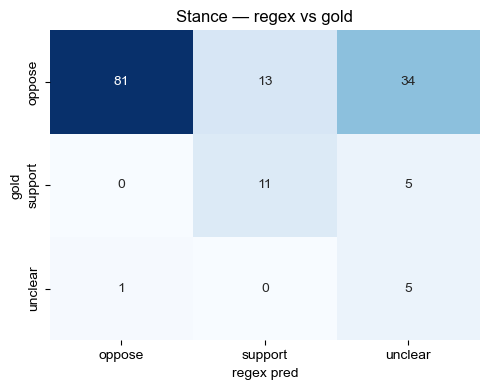

In [17]:
# stance precision/recall/F1 
labels=["oppose","support","unclear"]
sm={"Oppose":"oppose","Support":"support","Unclear":"unclear","Attachment only / unknown":"unclear"}
gold_stance = E["gold_stance"].str.strip().str.lower()
regex_stance= E["regex_stance"].str.strip().str.lower()
print(f"STANCE — regex vs gold:  accuracy={accuracy_score(gold_stance,regex_stance):.3f}")
print(classification_report(gold_stance,regex_stance,labels=labels,zero_division=0))

cm=confusion_matrix(gold_stance,regex_stance,labels=labels)
import seaborn as sns
plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=labels,yticklabels=labels,cbar=False)
plt.xlabel("regex pred"); plt.ylabel("gold"); plt.title("Stance — regex vs gold")
plt.tight_layout(); plt.savefig("regex_stance_cm.png",dpi=150,facecolor="white"); plt.show()


## 6. Read-out


access 138 rows

                           REGEX       LLM
micro Precision            0.861     0.691
micro Recall               0.722     0.903
micro F1                   0.786     0.783

                 topic  regex_recall  llm_recall  regex_f1  llm_f1
       oil_spill_risk          0.79        0.89      0.87    0.82
    climate_emissions          0.90        1.00      0.94    0.95
          air_quality          0.50        0.92      0.65    0.79
environmental_justice          0.89        0.97      0.82    0.56
      marine_wildlife          0.71        0.94      0.82    0.87
            fisheries          0.15        0.92      0.25    0.62
       wetlands_coast          0.68        0.74      0.65    0.61
    national_interest          0.64        0.77      0.70    0.79

STANCE accuracy —  regex: 0.667   LLM: 0.978


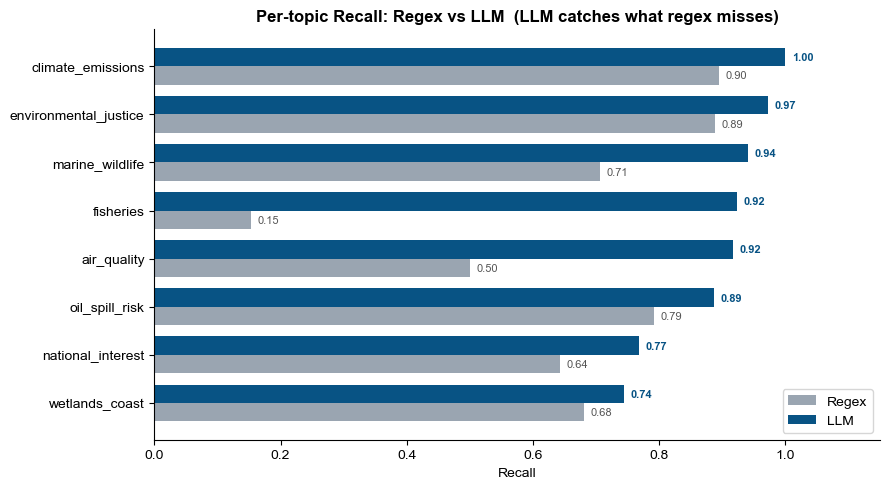

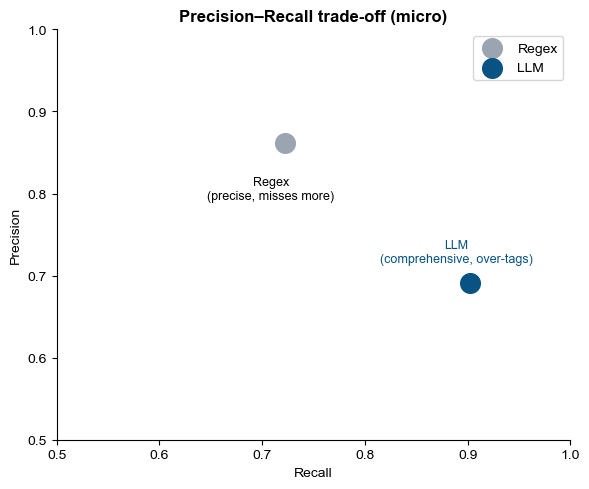

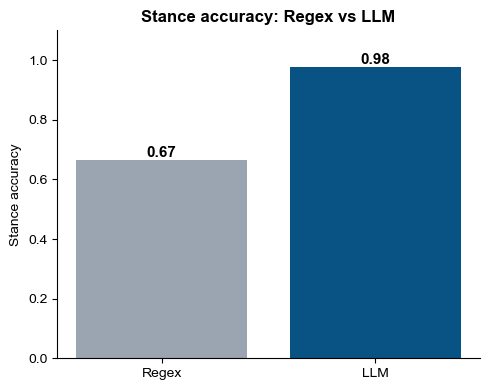


3 fig saved: regex_vs_llm_recall.png / _tradeoff.png / _stance.png


In [18]:
# regex vs LLM vs gold comparison
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

plt.rcParams['font.family']='sans-serif'
plt.rcParams['font.sans-serif']=['Calibri','Arial','DejaVu Sans']
NAVY,GREEN='#085384','#1B4332'
TOPIC_CODES=['oil_spill_risk','climate_emissions','air_quality','environmental_justice',
             'marine_wildlife','fisheries','wetlands_coast','national_interest']

# read data
gold = pd.read_csv("label_done_150.csv")
main = pd.read_csv("cleaned_comments_ver2.csv", low_memory=False)
llm  = pd.read_csv("full_llm_UNIQUE.csv")

# gold + regex merge
m = gold.merge(main[['Document ID','stance']+TOPIC_CODES], on='Document ID', how='left')
m = m.merge(llm[['Document ID','llm_topics','llm_stance','llm_failed']], on='Document ID', how='left')
m = m[m['llm_failed'] != True].copy()          
print(f"access {len(m)} rows\n")

def parse(s): return [t for t in str(s).replace(' ','').split('|') if t in TOPIC_CODES]
mlb = MultiLabelBinarizer(classes=TOPIC_CODES)

Y = mlb.fit_transform(m['gold_topics'].apply(parse))                    
R = m[TOPIC_CODES].fillna(False).astype(bool).astype(int).values       
L = mlb.transform(m['llm_topics'].apply(parse))                        

def scores(Y,P):
    out={}
    for avg in ['micro','macro']:
        p,r,f,_=precision_recall_fscore_support(Y,P,average=avg,zero_division=0)
        out[avg]=(p,r,f)
    p,r,f,sup=precision_recall_fscore_support(Y,P,average=None,zero_division=0,labels=range(len(TOPIC_CODES)))
    out['per']=(p,r,f,sup)
    return out

rs, ls = scores(Y,R), scores(Y,L)

print("="*55)
print(f"{'':22}{'REGEX':>10}{'LLM':>10}")
print(f"{'micro Precision':22}{rs['micro'][0]:>10.3f}{ls['micro'][0]:>10.3f}")
print(f"{'micro Recall':22}{rs['micro'][1]:>10.3f}{ls['micro'][1]:>10.3f}")
print(f"{'micro F1':22}{rs['micro'][2]:>10.3f}{ls['micro'][2]:>10.3f}")
print("="*55)

# per-topic comparison
cmp = pd.DataFrame({
    'topic':TOPIC_CODES,
    'regex_recall':rs['per'][1].round(2),
    'llm_recall':ls['per'][1].round(2),
    'regex_f1':rs['per'][2].round(2),
    'llm_f1':ls['per'][2].round(2),
})
print("\n", cmp.to_string(index=False))

# stance
sm={'Oppose':'oppose','Support':'support','Unclear':'unclear','Attachment only / unknown':'unclear'}
rs_stance = accuracy_score(m['gold_stance'].str.lower(), m['stance'].map(sm).fillna('unclear'))
ls_stance = accuracy_score(m['gold_stance'].str.lower(), m['llm_stance'].str.lower())
print(f"\nSTANCE accuracy —  regex: {rs_stance:.3f}   LLM: {ls_stance:.3f}")

# Fig comparison
fig,ax=plt.subplots(figsize=(9,5))
y=np.arange(len(TOPIC_CODES)); h=0.38
order=np.argsort(ls['per'][1])                       
codes=[TOPIC_CODES[i] for i in order]
rr=[rs['per'][1][i] for i in order]; lr=[ls['per'][1][i] for i in order]
ax.barh(y-h/2, rr, h, label='Regex', color='#9AA5B1')
ax.barh(y+h/2, lr, h, label='LLM',   color=NAVY)
ax.set_yticks(y); ax.set_yticklabels(codes)
for i in range(len(y)):
    ax.text(rr[i]+0.01, i-h/2, f'{rr[i]:.2f}', va='center', fontsize=8, color='#555')
    ax.text(lr[i]+0.01, i+h/2, f'{lr[i]:.2f}', va='center', fontsize=8, color=NAVY, weight='bold')
ax.set_xlim(0,1.15); ax.set_xlabel('Recall')
ax.set_title('Per-topic Recall: Regex vs LLM  (LLM catches what regex misses)',fontsize=12,weight='bold')
ax.legend(loc='lower right')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig('regex_vs_llm_recall.png',dpi=150,facecolor='white'); plt.show()

# Fig 2
fig,ax=plt.subplots(figsize=(6,5))
ax.scatter(rs['micro'][1], rs['micro'][0], s=200, color='#9AA5B1', label='Regex', zorder=3)
ax.scatter(ls['micro'][1], ls['micro'][0], s=200, color=NAVY, label='LLM', zorder=3)
ax.annotate('Regex\n(precise, misses more)', (rs['micro'][1],rs['micro'][0]),
            textcoords="offset points", xytext=(-10,-40), fontsize=9, ha='center')
ax.annotate('LLM\n(comprehensive, over-tags)', (ls['micro'][1],ls['micro'][0]),
            textcoords="offset points", xytext=(-10,15), fontsize=9, ha='center', color=NAVY)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_xlim(0.5,1); ax.set_ylim(0.5,1)
ax.set_title('Precision–Recall trade-off (micro)',fontsize=12,weight='bold')
ax.legend()
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig('regex_vs_llm_tradeoff.png',dpi=150,facecolor='white'); plt.show()

# FIg 3 stance
fig,ax=plt.subplots(figsize=(5,4))
bars=ax.bar(['Regex','LLM'],[rs_stance,ls_stance],color=['#9AA5B1',NAVY])
for b,v in zip(bars,[rs_stance,ls_stance]):
    ax.text(b.get_x()+b.get_width()/2, v+0.01, f'{v:.2f}', ha='center', fontsize=11, weight='bold')
ax.set_ylim(0,1.1); ax.set_ylabel('Stance accuracy')
ax.set_title('Stance accuracy: Regex vs LLM',fontsize=12,weight='bold')
for s in ['top','right']: ax.spines[s].set_visible(False)
plt.tight_layout(); plt.savefig('regex_vs_llm_stance.png',dpi=150,facecolor='white'); plt.show()

print("\n3 fig saved: regex_vs_llm_recall.png / _tradeoff.png / _stance.png")